In [1]:
# subsample SML analysis 
# Savor, P., & Wilson, M. (2014). Asset pricing: A tale of two days. Journal of Financial Economics, 113(2), 171-201.
# Chan, K. F., & Marsh, T. (2022). Asset pricing on earnings announcement days. Journal of Financial Economics, 144(3), 1022-1042.

import sys; sys.path.insert(0, ".")
import pandas as pd
import matplotlib.pyplot as plt

from constants import (
    ret_path,
)
from decomposition import (
    summarize_daily_rg_lnf_subsample_stats,
)
from port_sort import (
    build_sml_panel,
    plot_sml_conditional,
    plot_sml_days,
    run_sml_fm_by_quintiles,
    print_latex_sml_fm_table,
)


In [2]:
# Build SML panel (daily return only), load FF6 daily, and load announcement-day flags
from pathlib import Path

beta_col = "Beta252d"
k_groups = 10

sml_panel = build_sml_panel(beta_col=beta_col)
ff6_daily = pd.read_csv(ret_path + "ff6_daily_returns.csv")

announcement_dates = pd.read_csv(Path(ret_path).parent / "announcement_dates.csv")
announcement_dates["date"] = pd.to_datetime(announcement_dates["date"]).dt.strftime("%Y%m%d").astype(int)
announcement_dates["macro_day"] = announcement_dates[["cpi_day", "ppi_day", "unrate_day"]].max(axis=1).astype(int)
# fomc_day is scheduled-only upstream (data.get_announcement_dates).
days_df = announcement_dates[["date", "lead_day", "macro_day", "fomc_day"]].copy()
days_df[["lead_day", "macro_day", "fomc_day"]] = days_df[["lead_day", "macro_day", "fomc_day"]].astype(int)
non_special_days = days_df.loc[days_df[["lead_day", "macro_day", "fomc_day"]].sum(axis=1).eq(0), ["date"]]
sml_panel_non_special = sml_panel.merge(non_special_days, on="date", how="inner")


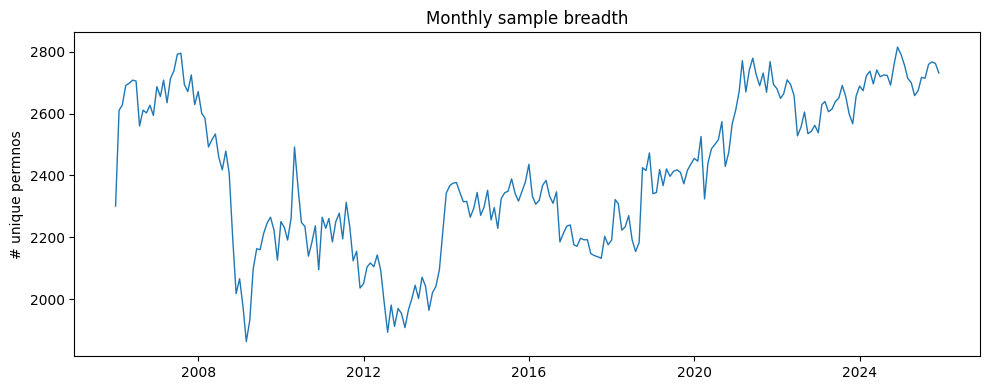

In [3]:
# Plot sample breadth: number of unique permnos per month
n_month = sml_panel.groupby("yyyymm")["permno"].nunique().reset_index(name="n_permno")
n_month["dt"] = pd.to_datetime(n_month["yyyymm"].astype(str), format="%Y%m")
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(n_month["dt"], n_month["n_permno"], lw=1.0)
ax.set_xlabel("")
ax.set_ylabel("# unique permnos")
ax.set_title("Monthly sample breadth")
ax.grid(False)
plt.tight_layout()
plt.show()


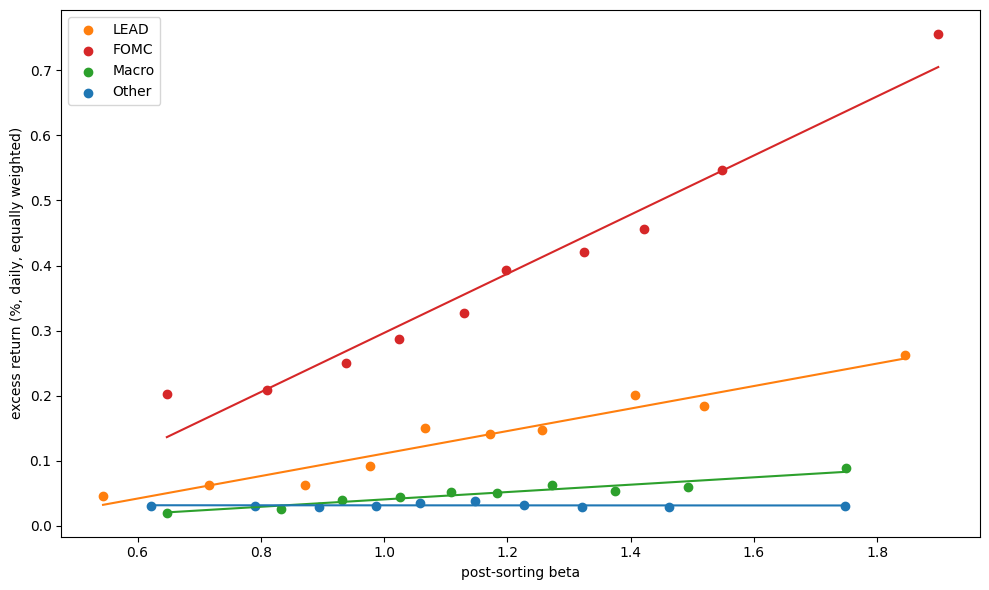

In [4]:
# Plot 1: SML by announcement-day subsamples (EW)
plot_sml_days(
    sml_panel,
    days_df,
    ff6_daily,
    eqw=True,
    save_filename="sml_ew_days.pdf",
    k_groups=k_groups,
)


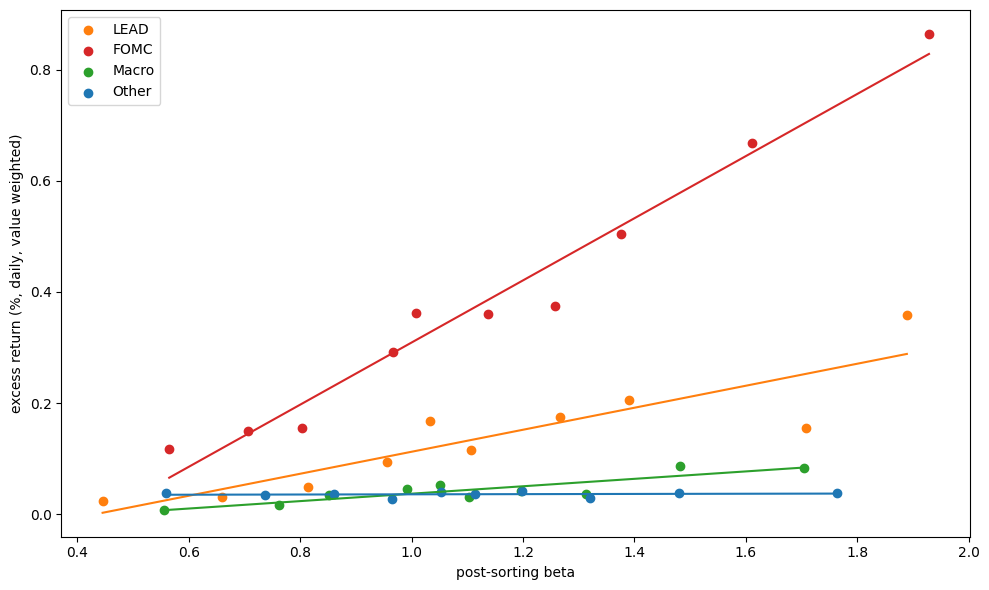

In [5]:
# Plot 2: SML by announcement-day subsamples (VW)
plot_sml_days(
    sml_panel,
    days_df,
    ff6_daily,
    eqw=False,
    save_filename="sml_vw_days.pdf",
    k_groups=k_groups,
)


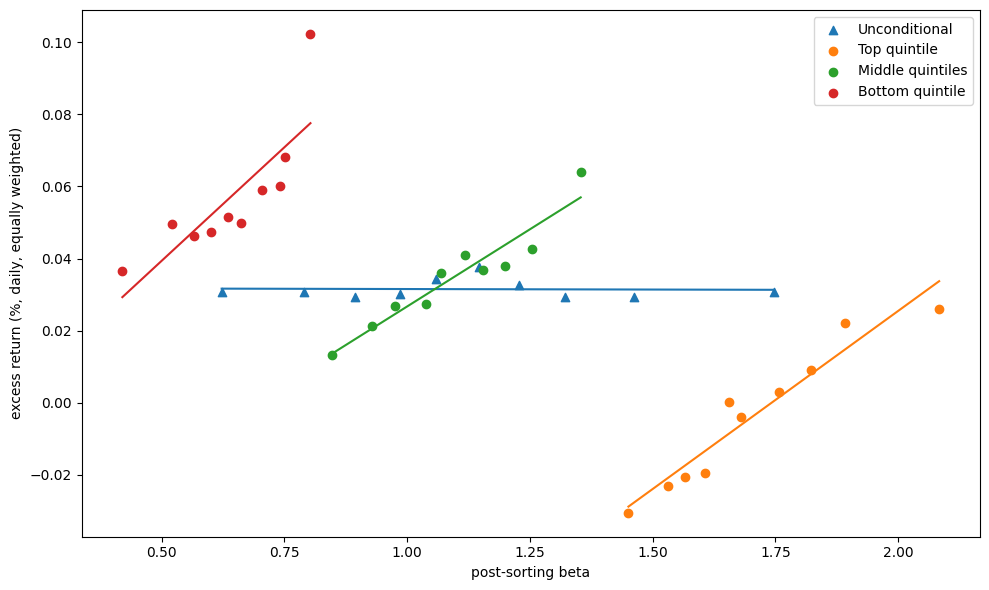

In [6]:
# Plot 3: conditional SML (EW) but only for non-special days (i.e. not a LEAD, FOMC, Macro)
plot_sml_conditional(
    sml_panel_non_special,
    ff6_daily,
    eqw=True,
    k_groups=k_groups,
    beta_col="beta_sort",
    low=0.2,
    high=0.8,
    save_filename="sml_ew_cond_nondays.pdf",
)


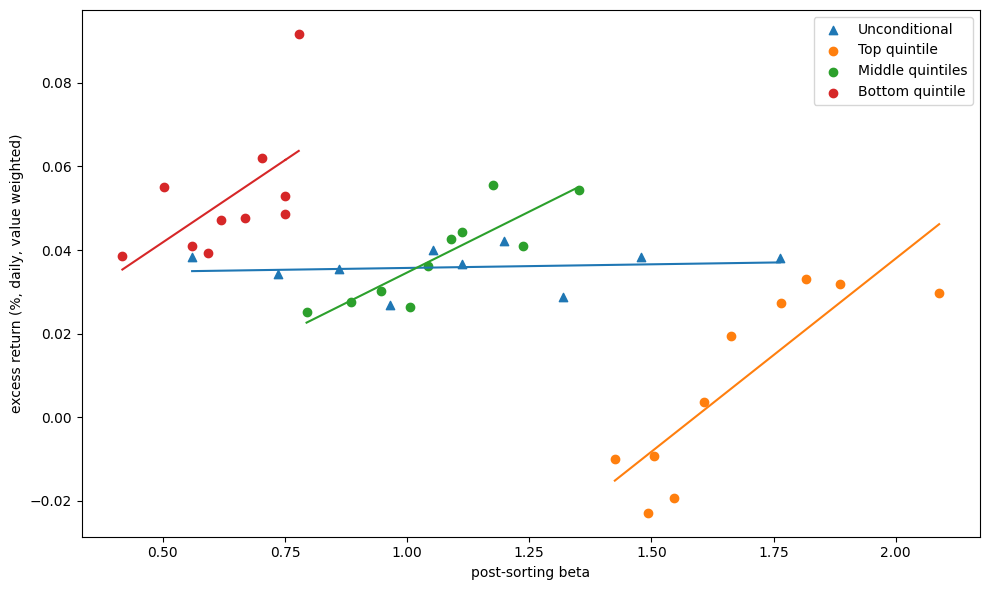

In [7]:
# Plot 4: conditional SML (VW) but only for non-special days (i.e. not a LEAD, FOMC, Macro)
plot_sml_conditional(
    sml_panel_non_special,
    ff6_daily,
    eqw=False,
    k_groups=k_groups,
    beta_col="beta_sort",
    low=0.2,
    high=0.8,
    save_filename="sml_vw_cond_nondays.pdf",
)


In [8]:
# FM regressions by news quintiles (EW): full/top/middle/bottom, non-special days only
fm_sml_ew = run_sml_fm_by_quintiles(
    sml_panel_non_special,
    eqw=True,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=10,
    low=0.2,
    high=0.8,
)


********************full-sample: equal-weight********************
[ret_ex]  Mean(Intercept) = 0.029, t(NW) = 2.23
[ret_ex]  Mean(beta)       = 0.001, t(NW) = 0.07
[ret_ex]  Avg adj-R^2     = 0.5901
********************top news quintile: equal-weight********************
[ret_ex]  Mean(Intercept) = -0.060, t(NW) = -1.90
[ret_ex]  Mean(beta)       = 0.040, t(NW) = 2.28
[ret_ex]  Avg adj-R^2     = 0.2735
********************middle news quintiles: equal-weight********************
[ret_ex]  Mean(Intercept) = -0.010, t(NW) = -0.69
[ret_ex]  Mean(beta)       = 0.040, t(NW) = 2.83
[ret_ex]  Avg adj-R^2     = 0.4226
********************bottom news quintile: equal-weight********************
[ret_ex]  Mean(Intercept) = 0.012, t(NW) = 0.96
[ret_ex]  Mean(beta)       = 0.057, t(NW) = 3.39
[ret_ex]  Avg adj-R^2     = 0.3009


In [9]:
# FM regressions by news quintiles (VW): full/top/middle/bottom, non-special days only
fm_sml_vw = run_sml_fm_by_quintiles(
    sml_panel_non_special,
    eqw=False,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=10,
    low=0.2,
    high=0.8,
)



********************full-sample: value-weight********************
[ret_ex]  Mean(Intercept) = 0.032, t(NW) = 1.99
[ret_ex]  Mean(beta)       = 0.002, t(NW) = 0.12
[ret_ex]  Avg adj-R^2     = 0.4631
********************top news quintile: value-weight********************
[ret_ex]  Mean(Intercept) = -0.050, t(NW) = -1.42
[ret_ex]  Mean(beta)       = 0.039, t(NW) = 1.87
[ret_ex]  Avg adj-R^2     = 0.1873
********************middle news quintiles: value-weight********************
[ret_ex]  Mean(Intercept) = 0.007, t(NW) = 0.43
[ret_ex]  Mean(beta)       = 0.028, t(NW) = 1.62
[ret_ex]  Avg adj-R^2     = 0.2997
********************bottom news quintile: value-weight********************
[ret_ex]  Mean(Intercept) = 0.021, t(NW) = 1.44
[ret_ex]  Mean(beta)       = 0.038, t(NW) = 2.02
[ret_ex]  Avg adj-R^2     = 0.2359


In [10]:
# Export FM summary table (EW vs VW) to LaTeX for non-special days
print_latex_sml_fm_table(
    fm_sml_ew=fm_sml_ew,
    fm_sml_vw=fm_sml_vw,
    lags=10,
    latex_filename="sml_fm_ew_vw_nondays.tex",
)

In [11]:
# Daily in-sample decomposition stats: Full vs Special days vs Non-special days
share = {
    "overall": days_df[["lead_day", "macro_day", "fomc_day"]].sum(axis=1).gt(0).mean(),
    "lead": days_df["lead_day"].mean(),
    "macro": days_df["macro_day"].mean(),
    "fomc": days_df["fomc_day"].mean(),
}
print(
    f"Special day shares | overall: {share['overall']:.2%}, "
    f"LEAD: {share['lead']:.2%}, Macro: {share['macro']:.2%}, FOMC: {share['fomc']:.2%}"
)

daily_ports, daily_stats = summarize_daily_rg_lnf_subsample_stats(
    days_df,
    ff6_daily,
    latex_filename="daily_rg_lnf_subsample_stats.tex",
)


Special day shares | overall: 21.33%, LEAD: 4.65%, Macro: 14.75%, FOMC: 3.16%

Daily In-sample Decomposition Stats
                          Full                     Special days            Non-special days      SR diff (Sp-NS)
                    Ret     Vol    SR         Ret     Vol    SR         Ret     Vol    SR      diff      t-stat
------------------------------------------------------------------------------------------------------------------------
Mkt-RF                10.79%   20.06%  0.54    17.36%   20.24%  0.86     9.01%   20.01%  0.45          0.41     0.76
Rg-RF                 13.31%   12.66%  1.05    15.22%   13.05%  1.17    12.79%   12.56%  1.02          0.15     0.26
MKTg-RF               12.79%   17.08%  0.75    13.19%   17.00%  0.78    12.68%   17.10%  0.74          0.03     0.06
LNF                   -2.00%   11.58% -0.17     4.17%   11.80%  0.35    -3.67%   11.51% -0.32          0.67     1.24
